In [1]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12,6)

In [ ]:
filename = 'yearly_full_release_long_format.csv'
df = pd.read_csv(filename)

# print(df.head())
# print(df.columns)
# print(df.shape)

print(df.describe())

                Year             EU           OECD            G20  \
count  370961.000000  348848.000000  348848.000000  348848.000000   
mean     2012.179628       0.131046       0.182747       0.087608   
std         7.295586       0.337451       0.386460       0.282725   
min      2000.000000       0.000000       0.000000       0.000000   
25%      2006.000000       0.000000       0.000000       0.000000   
50%      2012.000000       0.000000       0.000000       0.000000   
75%      2018.000000       0.000000       0.000000       0.000000   
max      2025.000000       1.000000       1.000000       1.000000   

                  G7          ASEAN          Value  YoY absolute change  \
count  348848.000000  348848.000000  350593.000000        255683.000000   
mean        0.033476       0.048098      70.737081             2.017624   
std         0.179876       0.213974     605.682082            28.231896   
min         0.000000       0.000000     -92.680000          -500.000000   
25%

In [33]:
# to remove missing values from important columns
important_cols = ['Year', 'Value']
df = df.dropna(subset=important_cols)

# convert numeric columns
numeric_cols = ['Value', 'YoY absolute change', 'YoY % change']
new_cols = ['Value (norm)', 'YoY absolute change (norm)', 'YoY % change (norm)']
df[new_cols] = df[numeric_cols].apply(lambda x: np.log10(x) if np.issubdtype(x.dtype, np.number) else x)

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# convert year
if 'Year' in df.columns:
    df['Year'] = pd.to_numeric(df['Year'], errors='coerce')


c:\Users\iancu\AppData\Local\Programs\Python\Python314\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\iancu\AppData\Local\Programs\Python\Python314\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [34]:
# specific dataframes
df_country = df[df['Area type'] == "Country or economy"]

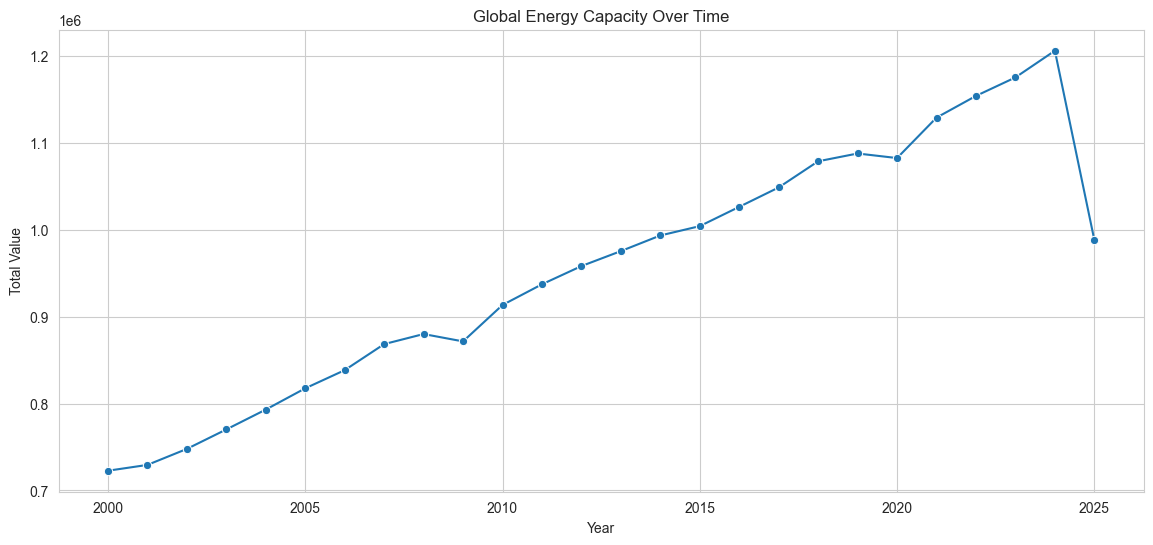

In [5]:
global_trend = df.groupby('Year')['Value'].sum().reset_index()

plt.figure(figsize=(14,6))
sns.lineplot(data=global_trend, x='Year', y='Value', marker='o')

plt.title('Global Energy Capacity Over Time')
plt.xlabel('Year')
plt.ylabel('Total Value')
plt.show()

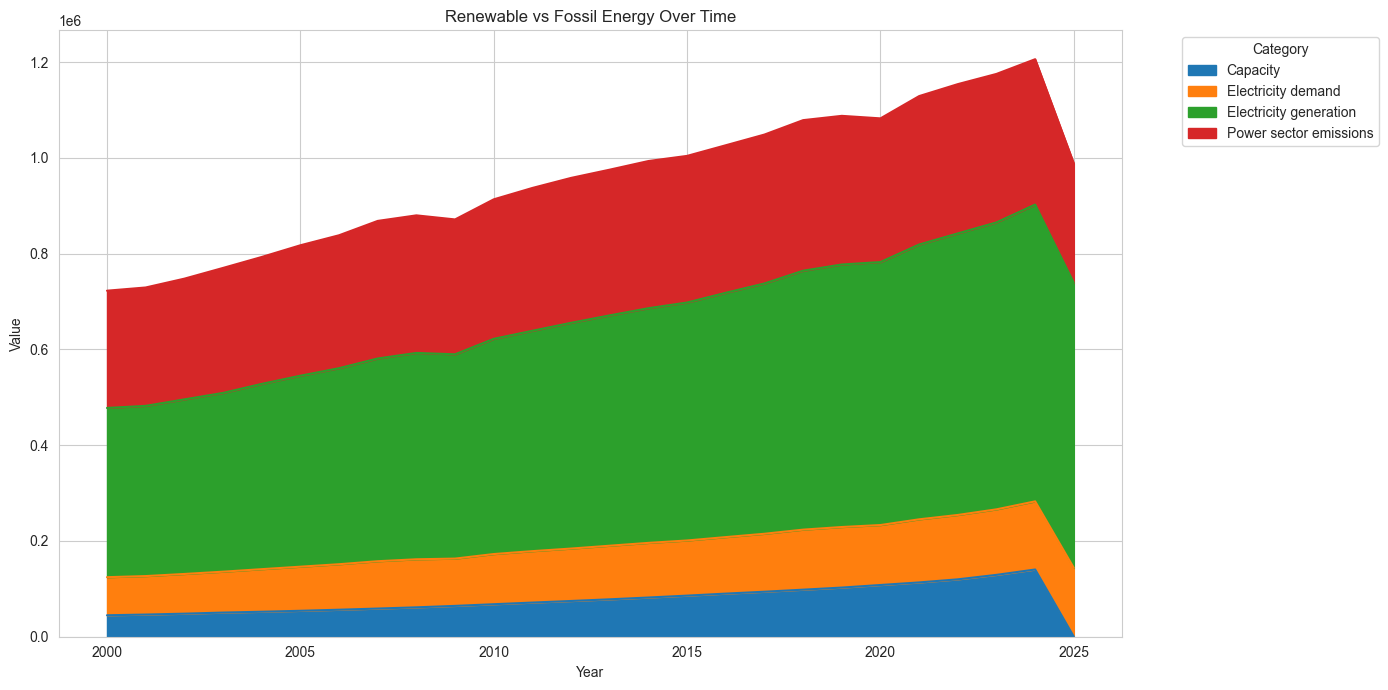

In [6]:
energy_transition = (
    df.groupby(['Year', 'Category'])['Value']
    .sum()
    .reset_index()
)

# Pivot table
pivot_transition = energy_transition.pivot(
    index='Year',
    columns='Category',
    values='Value'
).fillna(0)

# Remove categories containing negative values
pivot_transition = pivot_transition.loc[
    :,
    (pivot_transition >= 0).all()
]

# Plot
pivot_transition.plot.area(figsize=(14,7))

plt.title('Renewable vs Fossil Energy Over Time')
plt.xlabel('Year')
plt.ylabel('Value')
plt.legend(title='Category', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

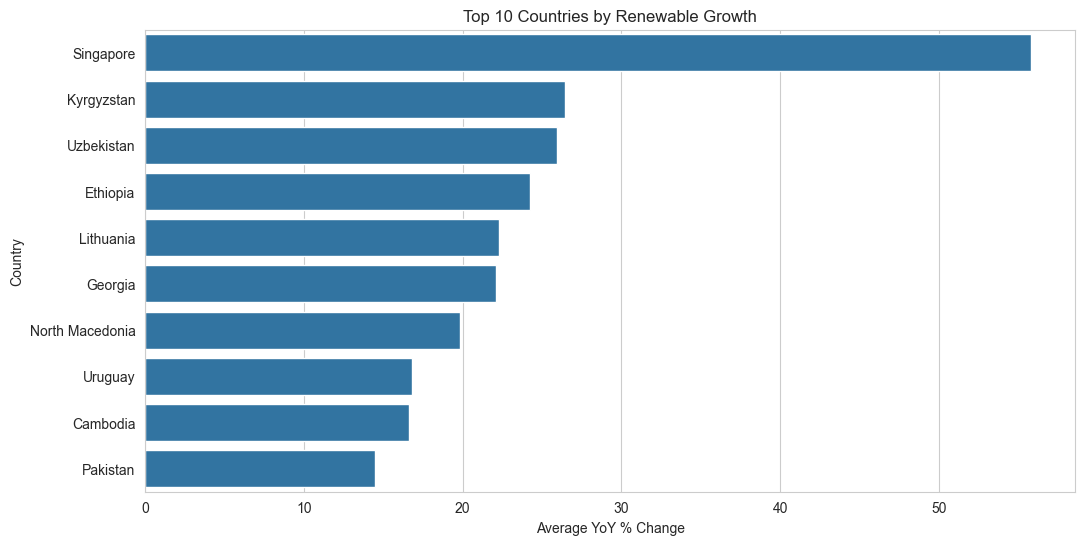

In [7]:
latest_year = df['Year'].max()

latest_df = df[df['Year'] == latest_year]

country_growth = (
    latest_df.groupby('Area')['YoY % change']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))
sns.barplot(x=country_growth.values, y=country_growth.index)

plt.title('Top 10 Countries by Renewable Growth')
plt.xlabel('Average YoY % Change')
plt.ylabel('Country')
plt.show()

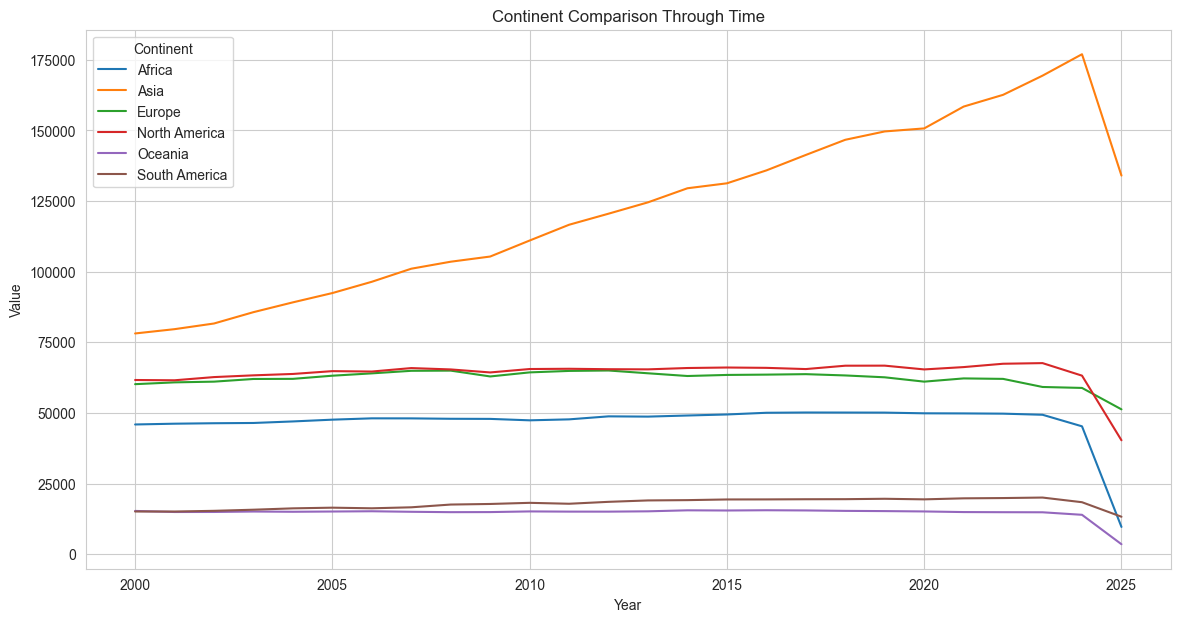

In [8]:
continent_trend = (
    df.groupby(['Year', 'Continent'])['Value']
    .sum()
    .reset_index()
)

plt.figure(figsize=(14,7))
sns.lineplot(data=continent_trend,
             x='Year',
             y='Value',
             hue='Continent')

plt.title('Continent Comparison Through Time')
plt.xlabel('Year')
plt.ylabel('Value')
plt.show()

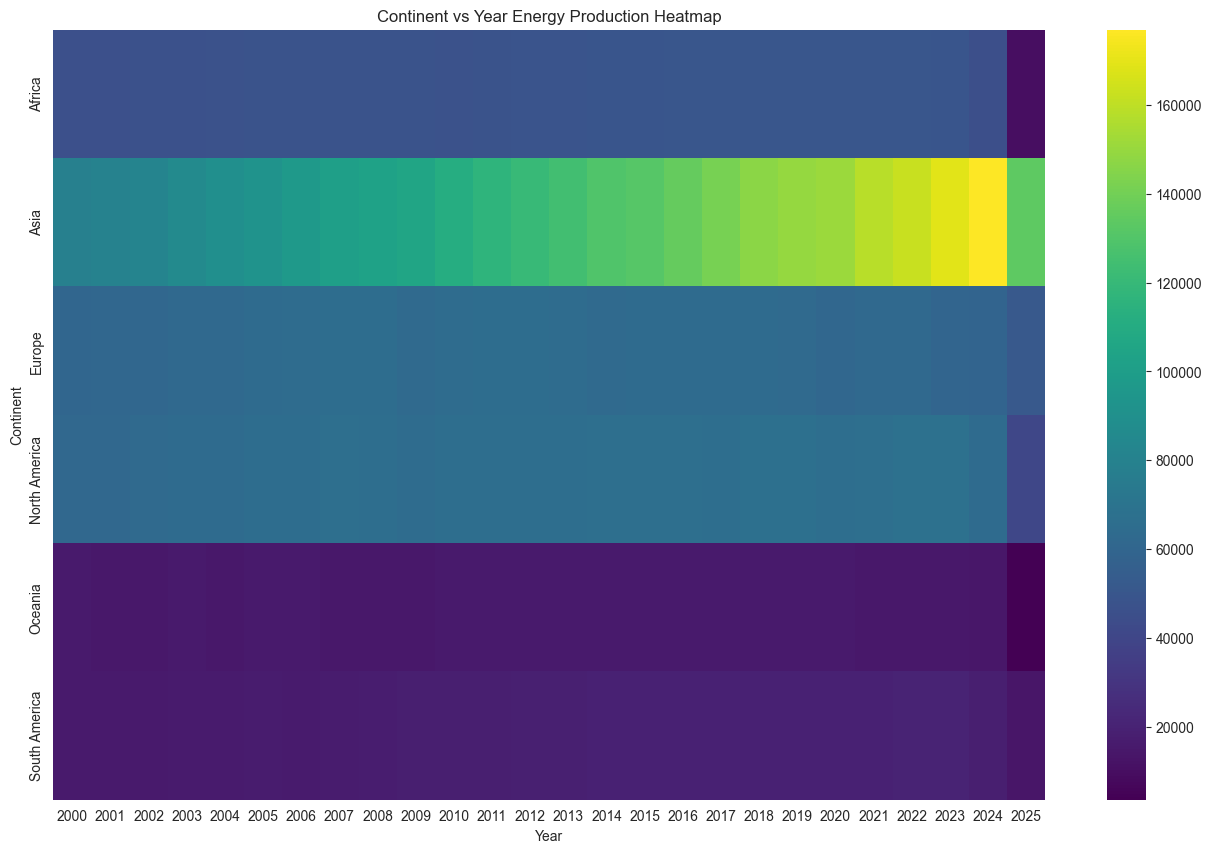

In [9]:
heatmap_data = (
    df.groupby(['Continent', 'Year'])['Value']
    .sum()
    .reset_index()
)

heatmap_pivot = heatmap_data.pivot(index='Continent', columns='Year', values='Value')

# Optional: limit to top countries for readability
heatmap_pivot = heatmap_pivot.head(20)

plt.figure(figsize=(16,10))
sns.heatmap(heatmap_pivot, cmap='viridis')

plt.title('Continent vs Year Energy Production Heatmap')
plt.xlabel('Year')
plt.ylabel('Continent')
plt.show()

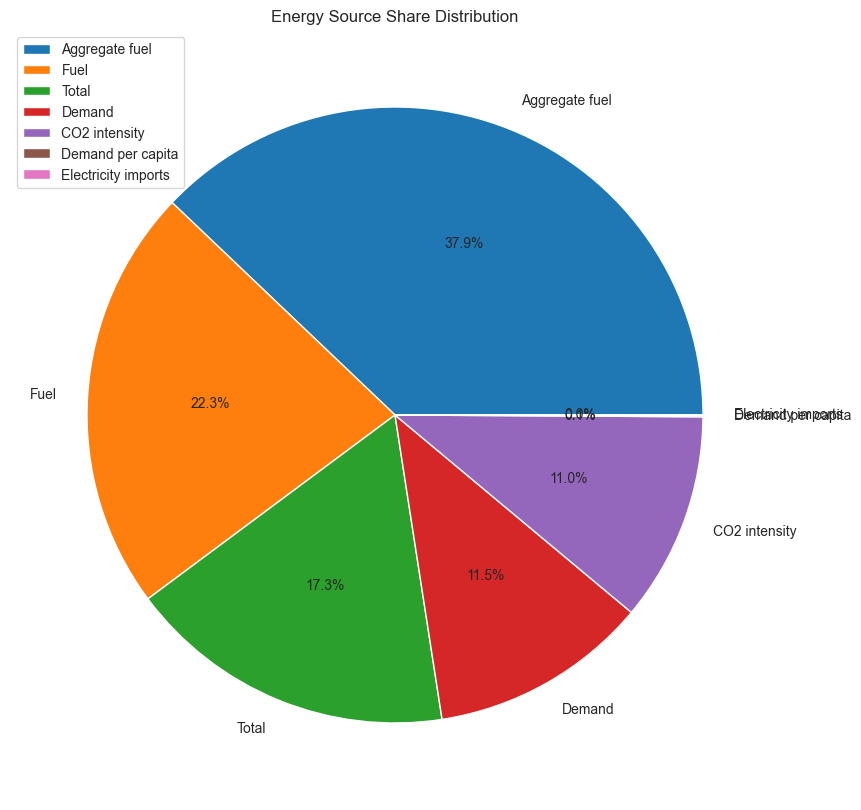

In [10]:
source_share = (
    df.groupby('Subcategory')['Value']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,10))
plt.pie(source_share.values,
        labels=source_share.index,
        autopct='%1.1f%%')
plt.legend()

plt.title('Energy Source Share Distribution')
plt.show()

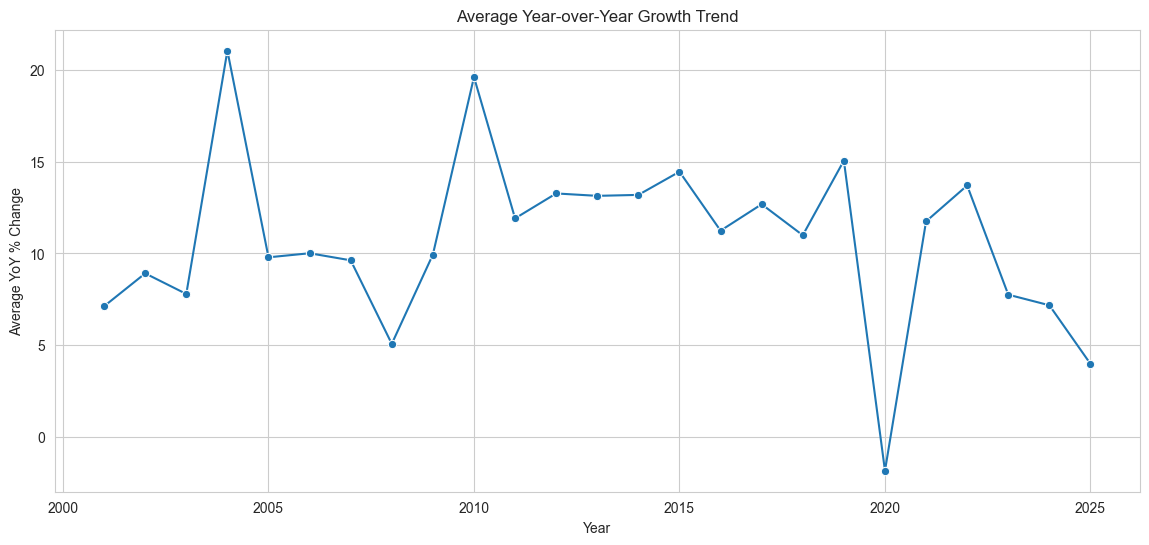

In [11]:
yoy_trend = (
    df.groupby('Year')['YoY % change']
    .mean()
    .reset_index()
)

plt.figure(figsize=(14,6))
sns.lineplot(data=yoy_trend,
             x='Year',
             y='YoY % change',
             marker='o')

plt.title('Average Year-over-Year Growth Trend')
plt.xlabel('Year')
plt.ylabel('Average YoY % Change')
plt.show()

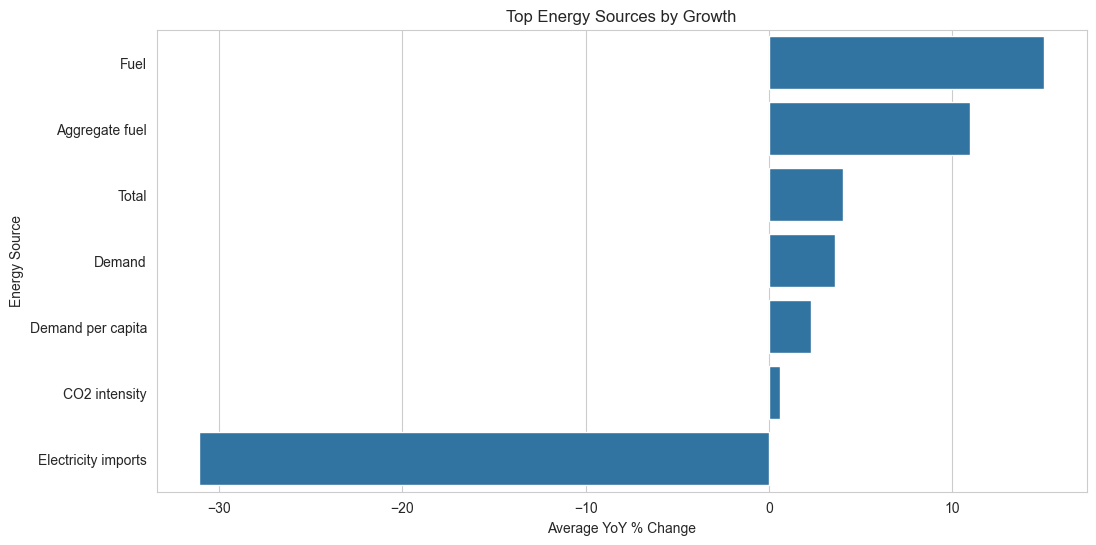

In [12]:
source_growth = (
    df.groupby('Subcategory')['YoY % change']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))
sns.barplot(x=source_growth.values,
            y=source_growth.index)

plt.title('Top Energy Sources by Growth')
plt.xlabel('Average YoY % Change')
plt.ylabel('Energy Source')
plt.show()

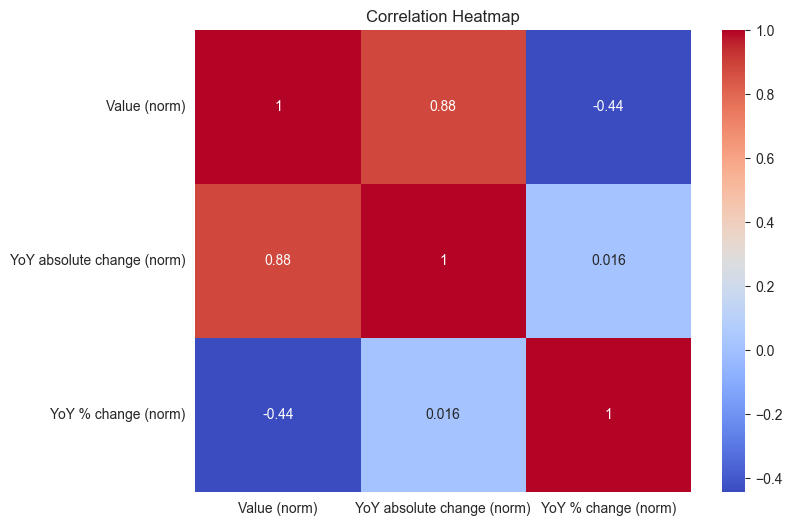

In [13]:
corr_cols = ['Value', 'YoY absolute change', 'YoY % change']
corr_cols_norm = ['Value (norm)', 'YoY absolute change (norm)', 'YoY % change (norm)']

corr_data = df[corr_cols_norm].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_data,
            annot=True,
            cmap='coolwarm')

plt.title('Correlation Heatmap')
plt.show()

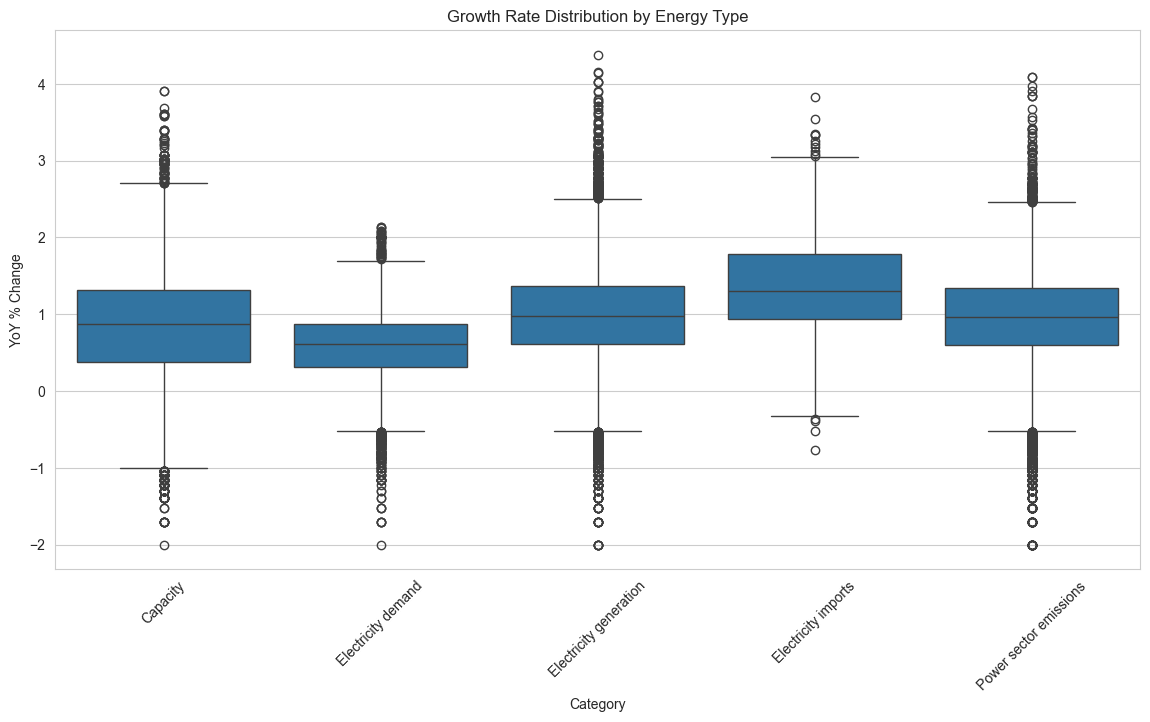

In [14]:
plt.figure(figsize=(14,7))

sns.boxplot(data=df,
            x='Category',
            y='YoY % change (norm)') # change if you want to see not-norm data

plt.xticks(rotation=45)
plt.title('Growth Rate Distribution by Energy Type')
plt.xlabel('Category')
plt.ylabel('YoY % Change')
plt.show()

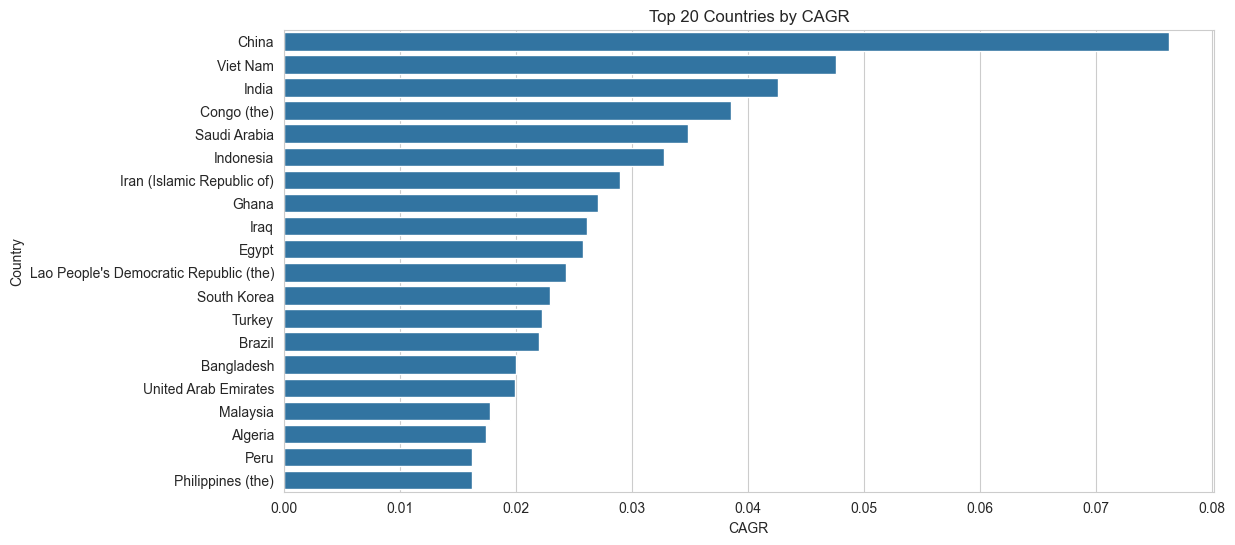

In [15]:
cagr_data = []

for country in df_country['Area'].dropna().unique():

    temp = df_country[df_country['Area'] == country]
    yearly = temp.groupby('Year')['Value'].sum().sort_index()

    if len(yearly) > 1:
        start_value = yearly.iloc[0]
        end_value = yearly.iloc[-1]
        n_years = yearly.index.max() - yearly.index.min()

        if start_value > 0 and n_years > 0:
            cagr = ((end_value / start_value) ** (1 / n_years)) - 1
            cagr_data.append([country, cagr])

cagr_df = pd.DataFrame(cagr_data, columns=['Country', 'CAGR'])

cagr_df = cagr_df.sort_values('CAGR', ascending=False).head(20)

plt.figure(figsize=(12,6))
sns.barplot(data=cagr_df,
            x='CAGR',
            y='Country')

plt.title('Top 20 Countries by CAGR')
plt.xlabel('CAGR')
plt.ylabel('Country')
plt.show()

In [22]:
import plotly.express as px

latest_year = df_country['Year'].max()

map_df = (
    df_country[df_country['Year'] == latest_year]
    .groupby('Area')['Value']
    .sum()
    .reset_index()
)

fig = px.choropleth(map_df,
                    locations='Area',
                    locationmode='country names',
                    color='Value',
                    title='Global Ene4rgy Distribution')

fig.update_layout(margin=dict(l=0, r=0, t=30, b=10))
fig.show()

C:\Users\iancu\AppData\Local\Temp\ipykernel_12956\3432791830.py:12: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(map_df,


In [29]:
import plotly.express as px

latest_year = df_country['Year'].max()
temp_df = df_country[df_country['Year'] == latest_year][df_country['Continent'] == 'Europe'][df_country['Area'] != 'Russian Federation (the)']

map_df = (
    temp_df
    .groupby('Area')['Value']
    .sum()
    .reset_index()
)

fig = px.choropleth(map_df,
                    locations='Area',
                    locationmode='country names',
                    color='Value',
                    title='Global Ene4rgy Distribution')

fig.update_layout(margin=dict(l=0, r=0, t=30, b=10))
fig.show()

C:\Users\iancu\AppData\Local\Temp\ipykernel_12956\558110972.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  temp_df = df_country[df_country['Year'] == latest_year][df_country['Continent'] == 'Europe'][df_country['Area'] != 'Russian Federation (the)']
C:\Users\iancu\AppData\Local\Temp\ipykernel_12956\558110972.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  temp_df = df_country[df_country['Year'] == latest_year][df_country['Continent'] == 'Europe'][df_country['Area'] != 'Russian Federation (the)']
C:\Users\iancu\AppData\Local\Temp\ipykernel_12956\558110972.py:13: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(map_df,


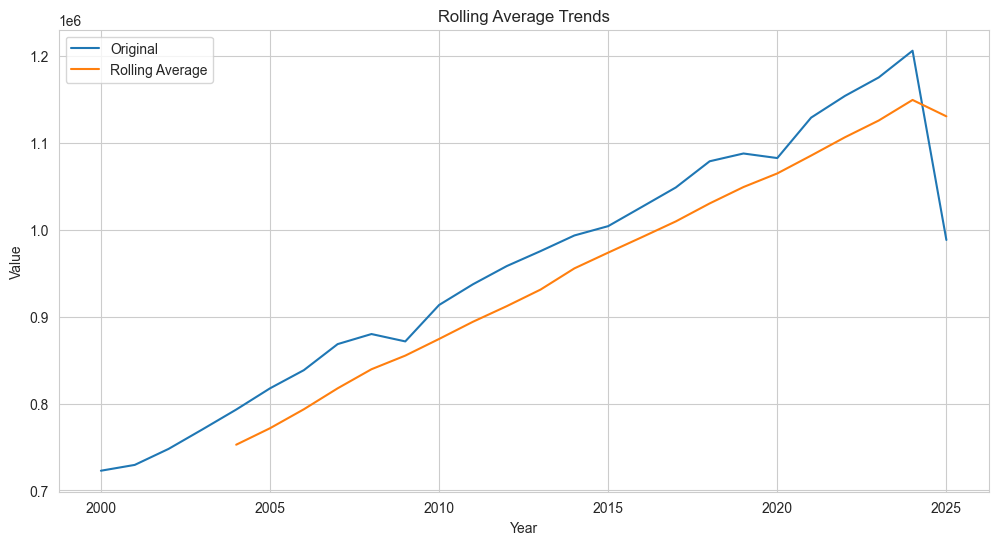

In [35]:
rolling_df = (
    df.groupby('Year')['Value']
    .sum()
    .reset_index()
)

rolling_df['Rolling Avg'] = rolling_df['Value'].rolling(window=5).mean()

plt.figure(figsize=(12,6))

sns.lineplot(data=rolling_df, x='Year', y='Value', label='Original')

sns.lineplot(data=rolling_df, x='Year', y='Rolling Avg', label='Rolling Average')

plt.title('Rolling Average Trends')
plt.show()

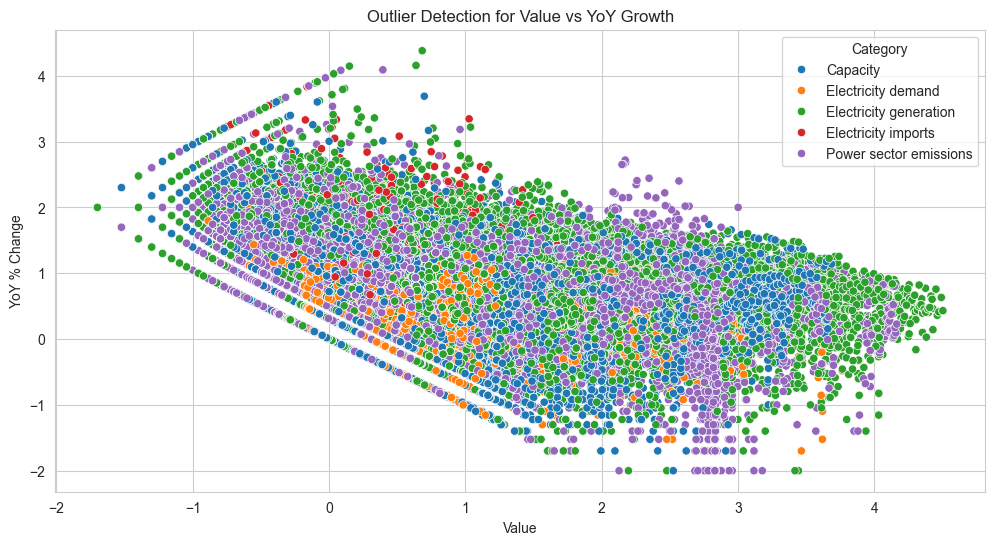

In [38]:
plt.figure(figsize=(12,6))

sns.scatterplot(data=df,
                x='Value (norm)',
                y='YoY % change (norm)',
                hue='Category')

plt.title('Outlier Detection for Value vs YoY Growth')
plt.xlabel('Value')
plt.ylabel('YoY % Change')
plt.show()